In [1]:
import pandas as pd

In [2]:
# load data into dataframe
df = pd.read_csv("data/MLINDIV_train_full.csv")
df.head()


,dates,times,X,Subject,eprocs,Task_type,Procedure,Sample,objlist,PairList,...,Nodes.S.L,Nodes.S.M.L,Num.Nodes...Turns..button.presses.,Press.S.L,Press.S.M.L,fmv_duration,path_dist_trav,euc_dist_trav,path_efficiencies,path_efficiencies_acc_only
0,2017-02-07,15:10:46,1,2,Explore-002-1,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,300.75,9.839334,NaN,NaN
1,2017-02-07,15:20:22,2,2,Explore-002-2,2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,285.75,13.894693,NaN,NaN
2,2017-02-07,15:29:23,3,2,Test_Trials_B_1-002-1,B1,TrialProc,1.0,20.0,8.0,...,S,S,5.0,S,M,1618.0,31.25,10.854147,2.55102,NaN
3,2017-02-07,15:29:23,4,2,Test_Trials_B_1-002-1,B1,TrialProc,2.0,61.0,7.0,...,S,M,8.0,S,S,1051.0,23.00,11.450982,1.00000,NaN
4,2017-02-07,15:29:23,5,2,Test_Trials_B_1-002-1,B1,TrialProc,3.0,67.0,1.0,...,S,M,10.0,L,M,1051.0,22.50,2.263846,1.00000,1.0


In [3]:
# define selectors to grab subsets of data
is_test = df["eprocs"].str.contains("Test")

In [5]:
# create animation for one path
path = df["e_paths"][2]
print(path)

start_node = df["StartAt"][2]
end_node = df["EndAt"][2]

print(start_node)
print(end_node)


U4 U1 R1 J1 D1 D4 D3 D2 E2 F2 F3 F4 E4 D4 D3 J3 J2 J3
W
N


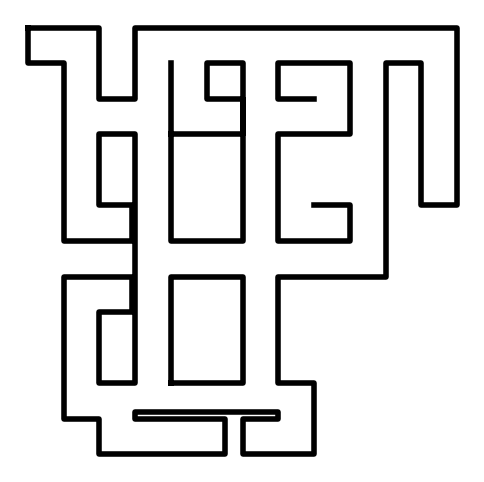

In [11]:
import matplotlib.pyplot as plt

# draw maze in plt
fig, ax = plt.subplots(figsize=(6, 6))

def draw_maze(ax):
    # starting from upper left
    external_structure = [
        # upper edge
        (0, 12), (2, 12), (2, 10), (3, 10), (3, 12), (12, 12),
        # right edge
        (12, 7), (11, 7), (11, 11), (10, 11), (10, 5), (7, 5), (7, 2), (8, 2), (8, 0),
        # bottom edge
        (6, 0), (6, 1), (7, 1), (7, 1.2), (3, 1.2), (3, 1), (5.5, 1), (5.5, 0), (2, 0), (2, 1), (1, 1),
        # right edge
        (1, 5), (2.9, 5), (2.9, 4), (2, 4), (2, 2), (3, 2), (3, 9), (2, 9), (2, 7), (2.9, 7), (2.9, 6), (1, 6), (1, 11), (0, 11), (0, 12)
    ]

    internal_structures = [
        # lower middle
        [(4, 2), (6, 2), (6, 5), (4, 5), (4, 2)],
        # middle
        [(4, 11), (4, 6), (6, 6), (6, 11), (5, 11), (5, 10), (6, 10), (6, 9), (4, 9)], 
        # upper right
        [(8, 10), (7, 10), (7, 11), (9, 11), (9, 9), (7, 9), (7, 6), (9, 6), (9, 7), (8, 7)]
    ]

    structures = internal_structures + [external_structure]

    for structure in structures:
        x_values, y_values = zip(*structure) # This unzips the start and end points into two tuples
        ax.plot(x_values, y_values, color='black', linewidth=4)

    #plot red objects now
    # red_circle_locations = [(.5, 11.5), (2.5, 4.5), (2.5, 6.5), (5.5, 9.5), (7.5, 10.5), (8.5, 6.5), (11.5, 7.5), (5, .5), (6.5, .5)]
    # for circle_loc in red_circle_locations:
    #     circle = plt.Circle(circle_loc, 0.2, color='r')
    #     ax.add_patch(circle)

    # set limits so that plt doesnt jiggle things when the person triangle reaches the edges
    lims = [-0.5, 12.5]
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    return ax

letter_code_to_coords_nonoffset = {
    "A": (2, 12), "B": (4, 12), "C": (5, 12),
    "D": (7, 12), "E": (10, 12), "F": (12, 12),
    "G": (2, 10), "H": (4, 10), "I": (5, 10),
    "J": (7, 10), "K": (9, 10), "L": (2, 7),
    "M": (10, 9), "N": (12, 9), "O": (8, 7.5),
    "P": (2, 5), "Q": (4, 6), "R": (7, 6),
    "S": (10, 6), "T": (4, 2.2), "U": (7, 2.2),
    "V": (3, 1), "W": (8, 1), "X": (3, 2),
    "Y": (5, 1), "Z": (2, 2)
}

# add offsets
letter_code_to_coords = {k: (v[0]-.7, v[1]-.7) for k,v in letter_code_to_coords_nonoffset.items()}

def add_letters(ax, letter_code_to_coords):
    for letter, (x,y) in letter_code_to_coords.items():
        ax.text(x, y, letter, fontsize=12, color="navy")

    return ax

def add_start_end(ax, start_loc, end_loc):
    circle = plt.Circle((start_loc[0]+.15, start_loc[1]+.15), 0.5, color='g', alpha=0.2)
    ax.add_patch(circle)

    circle = plt.Circle((end_loc[0]+.15, end_loc[1]+.15), 0.5, color='y', alpha=0.2)
    ax.add_patch(circle)

    return ax    

def add_person(ax, loc, dir, correct=True):
    if correct: color="green"
    else: color="red"

    # point in direction of dir
    point1 = (loc[0] + .9 * dir[0], loc[1] + .9 * dir[1])

    # if dir is in y we gotta flare in x
    point2 = (loc[0] - .25 * dir[1], loc[1] - .25 * dir[0])
    point3 = (loc[0] + .25 * dir[1], loc[1] + .25 * dir[0])

    triangle = plt.Polygon([point1, point2, point3], color=color, alpha=.1)
    ax.add_patch(triangle)

    return ax

def add_path_trace(ax, points_traversed,correct=True):
    if correct: color="green"
    else: color="red"

    x_values, y_values = zip(*points_traversed) # This unzips the start and end points into two tuples
    ax.plot(x_values, y_values, color=color, alpha=0.02, linewidth=5)
    return ax

ax = draw_maze(ax)
# ax = add_letters(ax, letter_code_to_coords)
# ax = add_start_end(ax, letter_code_to_coords[start_node], letter_code_to_coords[end_node])
# ax = add_person(ax, (1.5, 11.5), (0, -1))
# ax = add_path_trace(ax, [(1.5, 11.5), [2.5, 11.5]])

plt.axis('off')
plt.show()
fig.savefig("figures/plain-maze.png")


In [8]:
letter_code_to_coords
number_code_to_dir = {"1": (0 ,1), "2": (1, 0), "3": (0, -1), "4": (-1, 0)}

if path[-2:] == "NA": path = path[:-2]
states = path.split()

print([x[0] for x in states])
print([x[1] for x in states])

locs = [letter_code_to_coords[x[0]] for x in states]
dirs = [number_code_to_dir[x[1]] for x in states]

# cum_paths = [[]]
# for loc in locs:
#     cum_paths.append(cum_paths[-1].copy().extend(locs))

start_loc, end_loc = letter_code_to_coords[start_node], letter_code_to_coords[end_node]

# print("jsdlkf{dir}jklsdjf{dir}".format(dir="   "))

['U', 'U', 'R', 'J', 'D', 'D', 'D', 'D', 'E', 'F', 'F', 'F', 'E', 'D', 'D', 'J', 'J', 'J']
['4', '1', '1', '1', '1', '4', '3', '2', '2', '2', '3', '4', '4', '4', '3', '3', '2', '3']


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

def generate_image(person_loc, person_dir, i, start_loc=None, end_loc=None, path_trace=None, dir="animation_test", title=""):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax = draw_maze(ax)
    ax = add_letters(ax, letter_code_to_coords)
    ax = add_person(ax, person_loc, person_dir)

    if start_loc is not None and end_loc is not None:
        ax = add_start_end(ax, start_loc, end_loc)

    if path_trace is not None and len(path_trace) > 1:
        ax = add_path_trace(ax, path_trace)
        ax = add_path_trace(ax, [path_trace[-1], person_loc])
    
    ax.set_title(title)
    fig.savefig(f'{dir}/pic{i:04d}.png')
    plt.close()

dir_to_save = "with_trace"
Parallel(n_jobs=-1)(delayed(generate_image)(loc, dir, i, start_loc=start_loc, end_loc=end_loc, path_trace=locs[:i], dir=dir_to_save) for i, (loc, dir) in enumerate(zip(locs, dirs)))

# generate_image(locs[3], dirs[3], 3, start_loc=None, end_loc=None, path_trace=locs[:3], dir=dir_to_save)

# the y overwrites automatically so ipynb doesnt hang
os.system(f'ffmpeg -y -i {dir_to_save}/pic%04d.png -vf palettegen {dir_to_save}/palette.png')
os.system(f'ffmpeg -y -framerate 5 -i {dir_to_save}/pic%04d.png -i {dir_to_save}/palette.png -lavfi paletteuse -framerate 5 {dir_to_save}/aavideo.gif')

FileNotFoundError: [Errno 2] No such file or directory: '/Users/abbybertics/Documents/ucsb/mazedyn/mazedyn/with_trace/pic0001.png'

In [10]:
# okay let's make one function for doing one run...

def animate_one_path(row, dir_to_save, letter_code_to_coords=letter_code_to_coords, number_code_to_dir=number_code_to_dir):
    # EXTRACT INFO FROM ROW
    path = row["e_paths"]
    is_test = "Test" in row["eprocs"]
    
    # FIRST CONVERT PATH TO COORDS
    if path[-2:] == "NA": path = path[:-2] # this happens if the test ends unsuccessfully
    states = path.split()

    # THEN GENERATE IMAGE FOR EACH STEP IN PATH
    if is_test:
        locs = [letter_code_to_coords[chr(int(row["startPosition"])+65)]] + [letter_code_to_coords[x[0]] for x in states]
        dirs = [number_code_to_dir[str(int(row["startFacing"]))]] + [number_code_to_dir[x[1]] for x in states]
    
        start_loc, end_loc = letter_code_to_coords[row["StartAt"]], letter_code_to_coords[row["EndAt"]]
        Parallel(n_jobs=-1)(delayed(generate_image)(loc, dir, i, start_loc=start_loc, end_loc=end_loc, path_trace=locs[:i], title=f'test, accuracy={row["accuracy"]}' , dir=dir_to_save) for i, (loc, dir) in enumerate(zip(locs, dirs)))
    else:

        locs = [letter_code_to_coords[x[0]] for x in states]
        dirs = [number_code_to_dir[x[1]] for x in states]

        Parallel(n_jobs=-1)(delayed(generate_image)(loc, dir, i, path_trace=locs[:i], title="explore", dir=dir_to_save) for i, (loc, dir) in enumerate(zip(locs, dirs)))

    # THEN CONVERT TO GIF
    # the y overwrites automatically so ipynb doesnt hang
    os.system(f'ffmpeg -y -i {dir_to_save}/pic%04d.png -vf palettegen {dir_to_save}/palette.png')
    os.system(f'ffmpeg -y -framerate 10 -i {dir_to_save}/pic%04d.png -i {dir_to_save}/palette.png -lavfi paletteuse -framerate 10 {dir_to_save}/aavideo.gif')

# dir_to_save = "with_trace"
# animate_one_path(df.iloc[3], dir_to_save)

In [11]:
explore_df = df[df["eprocs"].str.contains("Explore")]

for i, row in explore_df.iterrows():

    dir_to_save = f"animations/explore/{i}"
    os.makedirs(dir_to_save, exist_ok=True)
    animate_one_path(row, dir_to_save)

sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found
sh: ffmpeg: command not found


KeyboardInterrupt: 

In [14]:
# okay now let's try doing all paths  at the same time

def generate_multi_path_image(df, i, start_node, end_node, letter_code_to_coords=letter_code_to_coords, number_code_to_dir=number_code_to_dir, path_trace=None, dir="multi_test", title=""):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax = draw_maze(ax)
    ax = add_letters(ax, letter_code_to_coords)
    ax = add_start_end(ax, letter_code_to_coords[start_node], letter_code_to_coords[end_node])

    # GO THROUGH EACH PERSON
    for _, row in df.iterrows():
        path = row["e_paths"] 
        if path[-2:] == "NA": path = path[:-2] # this happens if the test ends unsuccessfully
        
        states = path.split()

        locs = [letter_code_to_coords[start_node]] + [letter_code_to_coords[x[0]] for x in states]

        if i >= len(states): 
            if i > 0:
                ax = add_path_trace(ax, locs, correct=row["accuracy"])
            continue

        person_loc = letter_code_to_coords[states[i][0]]
        person_dir = number_code_to_dir[states[i][1]]

        ax = add_person(ax, person_loc, person_dir, correct=row["accuracy"])

        if i > 0:
            # print("adding trace?", locs)
            ax = add_path_trace(ax, locs[:i+1], correct=row["accuracy"])
    
    ax.set_title(title)
    fig.savefig(f'{dir}/pic{i:04d}.png')
    plt.close()
    
    
def animate_by_start_end(df, start_node, end_node, dir_to_save, letter_code_to_coords=letter_code_to_coords, number_code_to_dir=number_code_to_dir):
    os.makedirs(dir_to_save, exist_ok=True)

    df_this_path = df[(df["StartAt"] == start_node) & (df["EndAt"] == end_node)]
    # just to make it more tractable for now
    # df_this_path = df_this_path.iloc[:10]

    max_path_len = int(df_this_path["nodesturns_count"].max())

    # generate_multi_path_image(df_this_path, 5, start_node, end_node)
    Parallel(n_jobs=-1)(delayed(generate_multi_path_image)(df_this_path, i, start_node, end_node, dir=dir_to_save) for i in range(max_path_len))
    
    # # THEN CONVERT TO GIF
    # # the y overwrites automatically so ipynb doesnt hang
    os.system(f'ffmpeg -y -i {dir_to_save}/pic%04d.png -vf palettegen {dir_to_save}/palette.png')
    os.system(f'ffmpeg -y -framerate 5 -i {dir_to_save}/pic%04d.png -i {dir_to_save}/palette.png -lavfi paletteuse -framerate 5 {dir_to_save}/aavideo.gif')

# dir_to_save = "multi_test"
# animate_by_start_end(df, start_node="K", end_node="W", dir_to_save=dir_to_save)

In [15]:
for start_node, end_node in df.groupby(["StartAt", "EndAt"]).groups.keys():
      print(start_node, end_node)
      animate_by_start_end(df, start_node=start_node, end_node=end_node, dir_to_save=f'animations/test_by_start-end/{start_node+end_node}')
      # break

A I


ffmpeg version 4.2.2 Copyright (c) 2000-2019 the FFmpeg developers
  built with clang version 4.0.1 (tags/RELEASE_401/final)
  configuration: --prefix=/Users/abbybertics/opt/anaconda3/envs/mazedyn --cc=x86_64-apple-darwin13.4.0-clang --disable-doc --enable-avresample --enable-gmp --enable-hardcoded-tables --enable-libfreetype --enable-libvpx --enable-pthreads --enable-libopus --enable-postproc --enable-pic --enable-pthreads --enable-shared --enable-static --enable-version3 --enable-zlib --enable-libmp3lame --disable-nonfree --enable-gpl --enable-gnutls --disable-openssl --enable-libopenh264 --enable-libx264
  libavutil      56. 31.100 / 56. 31.100
  libavcodec     58. 54.100 / 58. 54.100
  libavformat    58. 29.100 / 58. 29.100
  libavdevice    58.  8.100 / 58.  8.100
  libavfilter     7. 57.100 /  7. 57.100
  libavresample   4.  0.  0 /  4.  0.  0
  libswscale      5.  5.100 /  5.  5.100
  libswresample   3.  5.100 /  3.  5.100
  libpostproc    55.  5.100 / 55.  5.100
Input #0, image2

A K


ffmpeg version 4.2.2 Copyright (c) 2000-2019 the FFmpeg developers
  built with clang version 4.0.1 (tags/RELEASE_401/final)
  configuration: --prefix=/Users/abbybertics/opt/anaconda3/envs/mazedyn --cc=x86_64-apple-darwin13.4.0-clang --disable-doc --enable-avresample --enable-gmp --enable-hardcoded-tables --enable-libfreetype --enable-libvpx --enable-pthreads --enable-libopus --enable-postproc --enable-pic --enable-pthreads --enable-shared --enable-static --enable-version3 --enable-zlib --enable-libmp3lame --disable-nonfree --enable-gpl --enable-gnutls --disable-openssl --enable-libopenh264 --enable-libx264
  libavutil      56. 31.100 / 56. 31.100
  libavcodec     58. 54.100 / 58. 54.100
  libavformat    58. 29.100 / 58. 29.100
  libavdevice    58.  8.100 / 58.  8.100
  libavfilter     7. 57.100 /  7. 57.100
  libavresample   4.  0.  0 /  4.  0.  0
  libswscale      5.  5.100 /  5.  5.100
  libswresample   3.  5.100 /  3.  5.100
  libpostproc    55.  5.100 / 55.  5.100
Input #0, image2

A L


...

Y W


ffmpeg version 4.2.2 Copyright (c) 2000-2019 the FFmpeg developers
  built with clang version 4.0.1 (tags/RELEASE_401/final)
  configuration: --prefix=/Users/abbybertics/opt/anaconda3/envs/mazedyn --cc=x86_64-apple-darwin13.4.0-clang --disable-doc --enable-avresample --enable-gmp --enable-hardcoded-tables --enable-libfreetype --enable-libvpx --enable-pthreads --enable-libopus --enable-postproc --enable-pic --enable-pthreads --enable-shared --enable-static --enable-version3 --enable-zlib --enable-libmp3lame --disable-nonfree --enable-gpl --enable-gnutls --disable-openssl --enable-libopenh264 --enable-libx264
  libavutil      56. 31.100 / 56. 31.100
  libavcodec     58. 54.100 / 58. 54.100
  libavformat    58. 29.100 / 58. 29.100
  libavdevice    58.  8.100 / 58.  8.100
  libavfilter     7. 57.100 /  7. 57.100
  libavresample   4.  0.  0 /  4.  0.  0
  libswscale      5.  5.100 /  5.  5.100
  libswresample   3.  5.100 /  3.  5.100
  libpostproc    55.  5.100 / 55.  5.100
Input #0, image2

nan nan


frame=   20 fps=0.0 q=-0.0 Lsize=      79kB time=00:00:03.81 bitrate= 169.0kbits/s speed=20.9x    
video:79kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.024858%


ValueError: cannot convert float NaN to integer